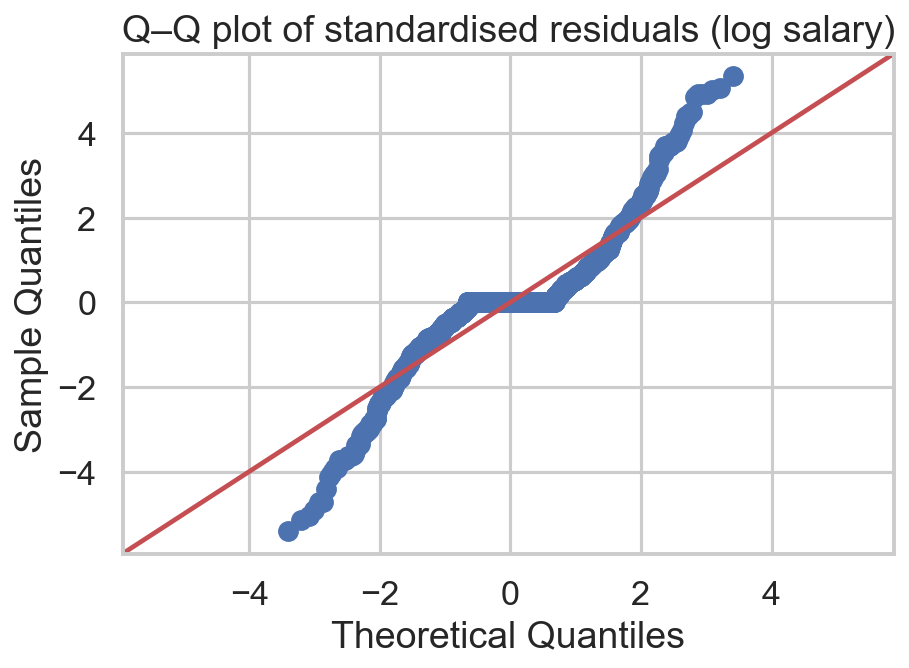

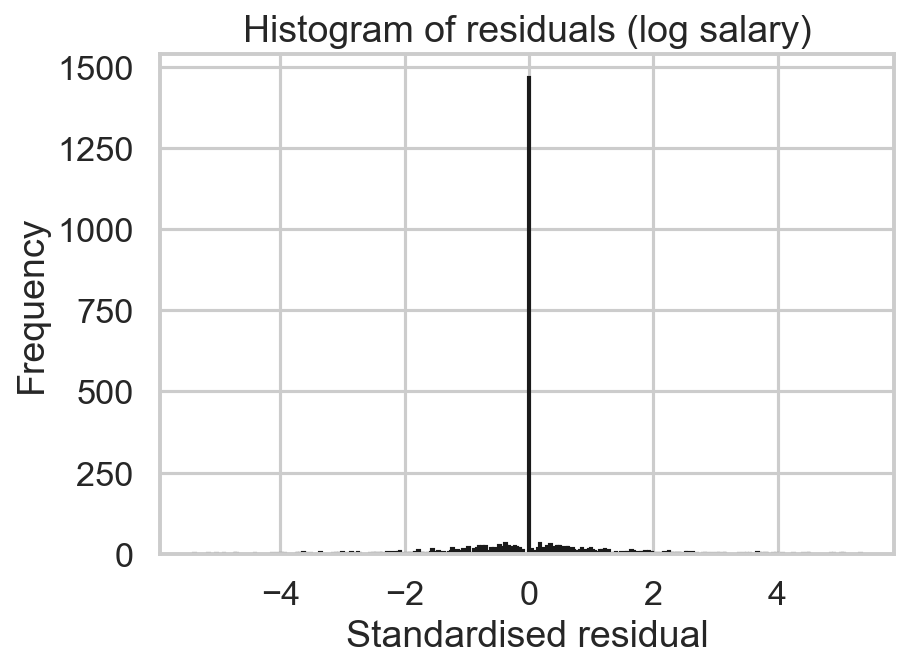


Shapiro–Wilk on log scale: W = 0.813, p = 2.114e-50
→ Residuals deviate significantly from normality.

=== 3-way ANOVA (log salary) ===
                     sum_sq    df             F         PR(>F)
C(gender)          0.403539   1.0    678.922959  4.027453e-133
C(age)            12.299374  40.0    517.317988   0.000000e+00
C(occupation)     80.270416   4.0  33762.149098   0.000000e+00
C(gender):C(age)   0.100422  40.0      4.223784   4.296445e-17


In [7]:
# ---------- 5. Log-transform and re-analyse --------------------------
import numpy as np
import scipy.stats as st

# ❶ Create new column (use the correct salary name!)
df["log_salary"] = np.log(df["middle_salary"])   # use 'middle_salary', not 'middel_salary'

# ❷ Fit the same factorial model on the log scale
model_log = smf.ols("log_salary ~ C(gender)*C(age)*C(occupation)", data=df).fit()

# ❸ Normality check on log‐scale residuals
resid_z = (model_log.resid - model_log.resid.mean()) / model_log.resid.std(ddof=1)

sm.qqplot(resid_z, line="45")
plt.title("Q–Q plot of standardised residuals (log salary)")
plt.tight_layout()
plt.show()

plt.hist(resid_z, bins="auto", edgecolor="k")
plt.xlabel("Standardised residual")
plt.ylabel("Frequency")
plt.title("Histogram of residuals (log salary)")
plt.tight_layout()
plt.show()

w, p_log = st.shapiro(model_log.resid)
print(f"\nShapiro–Wilk on log scale: W = {w:.3f}, p = {p_log:.4g}")
print("→ No evidence against residual normality." if p_log > 0.05
      else "→ Residuals deviate significantly from normality.")

# ❹ ANOVA table on the log scale
anova_log = sm.stats.anova_lm(model_log, typ=2)
print("\n=== 3-way ANOVA (log salary) ===")
print(anova_log.loc[["C(gender)", "C(age)", "C(occupation)", "C(gender):C(age)"]])


=== 3-way ANOVA (Type II) ===
                        sum_sq    df             F         PR(>F)
C(gender)         8.851106e+08   1.0    869.610220  4.760028e-165
C(age)            2.238880e+10  40.0    549.918039   0.000000e+00
C(occupation)     1.522341e+11   4.0  37392.032711   0.000000e+00
C(gender):C(age)  2.034050e+08  40.0      4.996072   4.428012e-22

Sex × Age interaction p = 4.43e-22  →  YES – the gender gap differs by age.


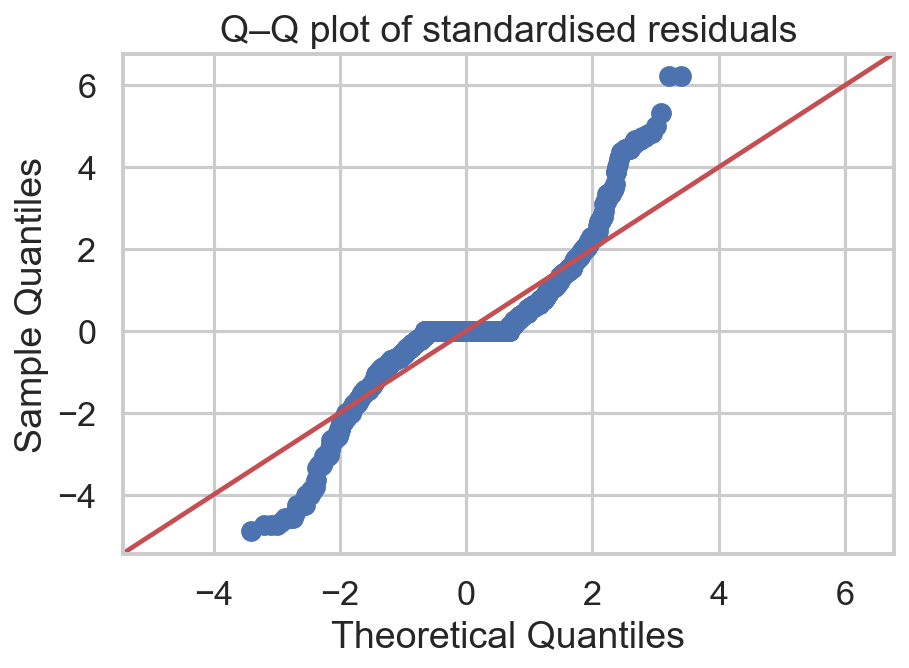

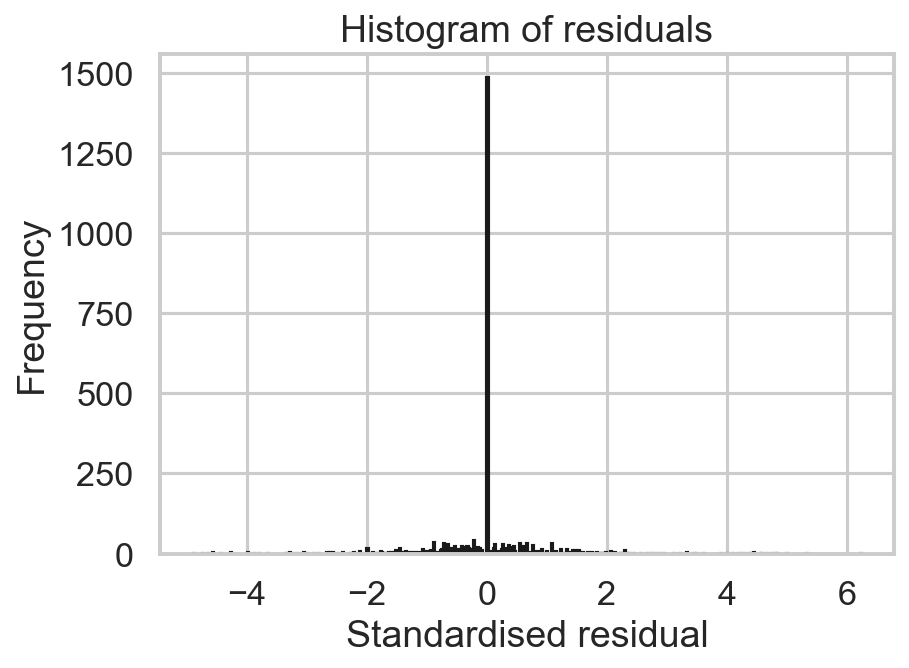


Shapiro–Wilk: W = 0.790, p = 2.298e-52
→ Residuals deviate significantly from normality.


/var/folders/xf/3h6xnmdj0jg__mms2zt6r6wc0000gn/T/ipykernel_30900/1046138005.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_tbl = (df.groupby(["age", "gender"])["middle_salary"]


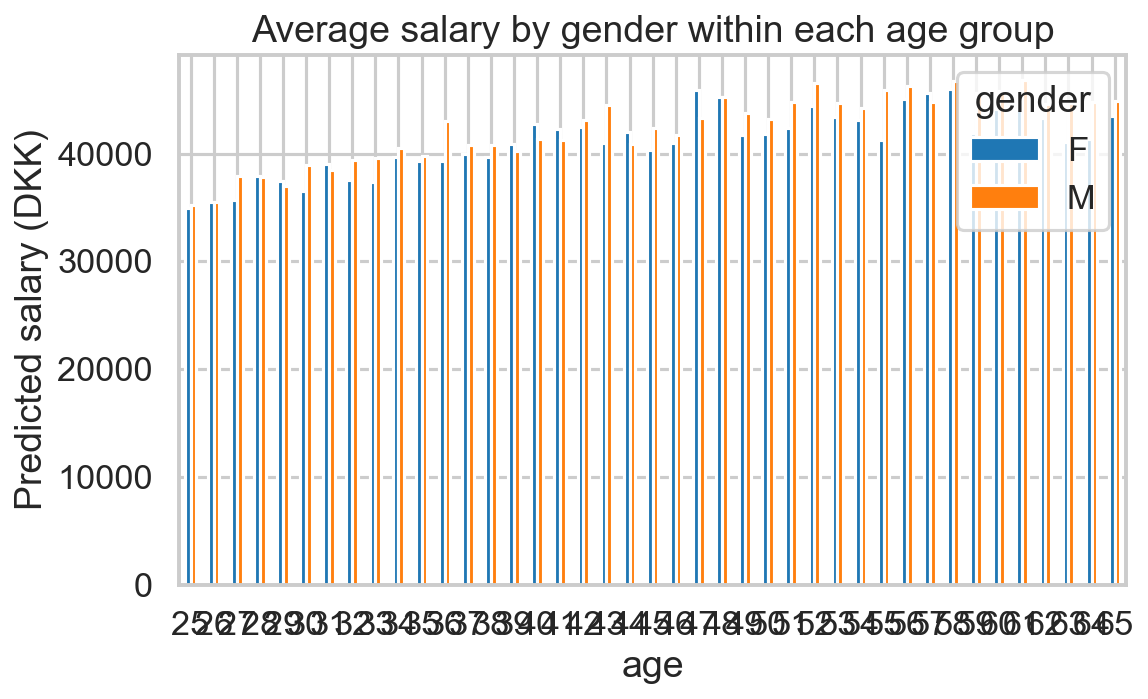

In [9]:
# gender_age_job_anova.py  --------------------------------------------
# Needs: pandas, statsmodels, matplotlib, scipy
# ---------------------------------------------------------------------
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import scipy.stats as st
import numpy as np

CSV = "/Users/vitusthaulow/Documents/GitHub/Project-in-Stat.-Eval.-02445/salaries_3000.csv"

# 1. Load the four columns we need
cols = ["gender", "age", "occupation", "middle_salary"]
df   = pd.read_csv(CSV, usecols=cols)

# 2. Treat grouping variables as factors
for col in ["gender", "age", "occupation"]:
    df[col] = df[col].astype("category")

# 3. Three-way ANOVA (Type II)
model = smf.ols("middle_salary ~ C(gender)*C(age)*C(occupation)", data=df).fit()
anova = sm.stats.anova_lm(model, typ=2)

print("\n=== 3-way ANOVA (Type II) ===")
print(anova.loc[["C(gender)", "C(age)", "C(occupation)", "C(gender):C(age)"]])

p = anova.loc["C(gender):C(age)", "PR(>F)"]
msg = "YES – the gender gap differs by age." if p < 0.05 else \
      "No – the gap is roughly constant across ages."
print(f"\nSex × Age interaction p = {p:.3g}  →  {msg}")

# 3 b. Residual normality diagnostics ---------------------------------
resid   = model.resid
resid_z = (resid - resid.mean()) / resid.std(ddof=1)       # standardiseret

# Q–Q-plot
sm.qqplot(resid_z, line="45")
plt.title("Q–Q plot of standardised residuals")
plt.tight_layout()
plt.show()

# Histogram
plt.hist(resid_z, bins="auto", edgecolor="k")
plt.xlabel("Standardised residual")
plt.ylabel("Frequency")
plt.title("Histogram of residuals")
plt.tight_layout()
plt.show()

# Shapiro–Wilk test
w, p_sh = st.shapiro(resid)
print(f"\nShapiro–Wilk: W = {w:.3f}, p = {p_sh:.4g}")
print("→ No evidence against residual normality."
      if p_sh > 0.05 else
      "→ Residuals deviate significantly from normality.")

# 4. Bar-plot with fixed colours --------------------------------------
colour_map = {"F": "#1f77b4",    # blue
              "M": "#ff7f0e"}    # orange

mean_tbl = (df.groupby(["age", "gender"])["middle_salary"]
              .mean()
              .unstack())        # rows = age, cols = gender

ax = mean_tbl.loc[:, ["F", "M"]].plot(
        kind="bar", figsize=(8, 5), rot=0,
        color=[colour_map["F"], colour_map["M"]])

ax.set_ylabel("Predicted salary (DKK)")
ax.set_title("Average salary by gender within each age group")
ax.legend(title="gender")
plt.tight_layout()
plt.show()


=== 2-way ANOVA + alder ===
                               sum_sq   df            F        PR(>F)
C(occupation)            1.536417e+11  4.0  7752.279487  0.000000e+00
C(gender)                8.881285e+08  1.0   179.248704  9.975851e-40
C(occupation):C(gender)  1.231663e+09  4.0    62.145863  1.729679e-50


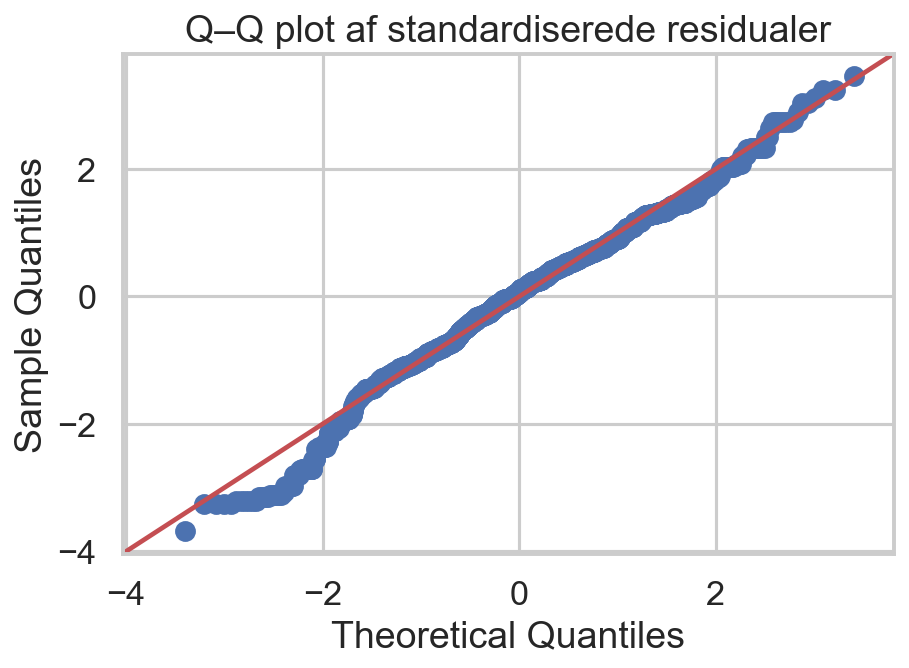

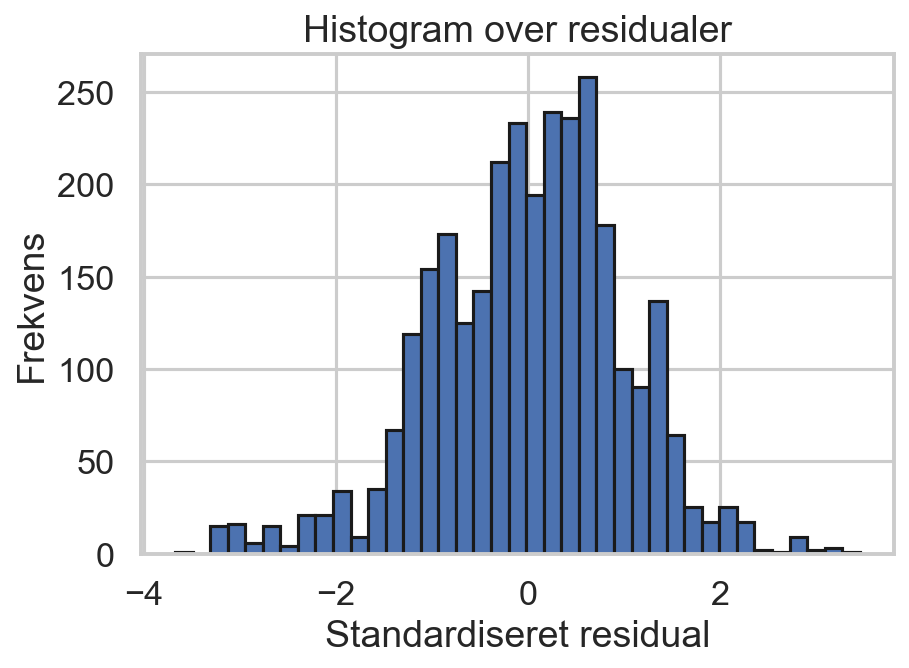


Shapiro–Wilk: W = 0.988, p = 2.545e-15
→ Residualerne afviger signifikant fra normalitet.


/var/folders/xf/3h6xnmdj0jg__mms2zt6r6wc0000gn/T/ipykernel_30900/1012869790.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_tbl = (df.groupby(["occupation", "gender"])["middle_salary"]


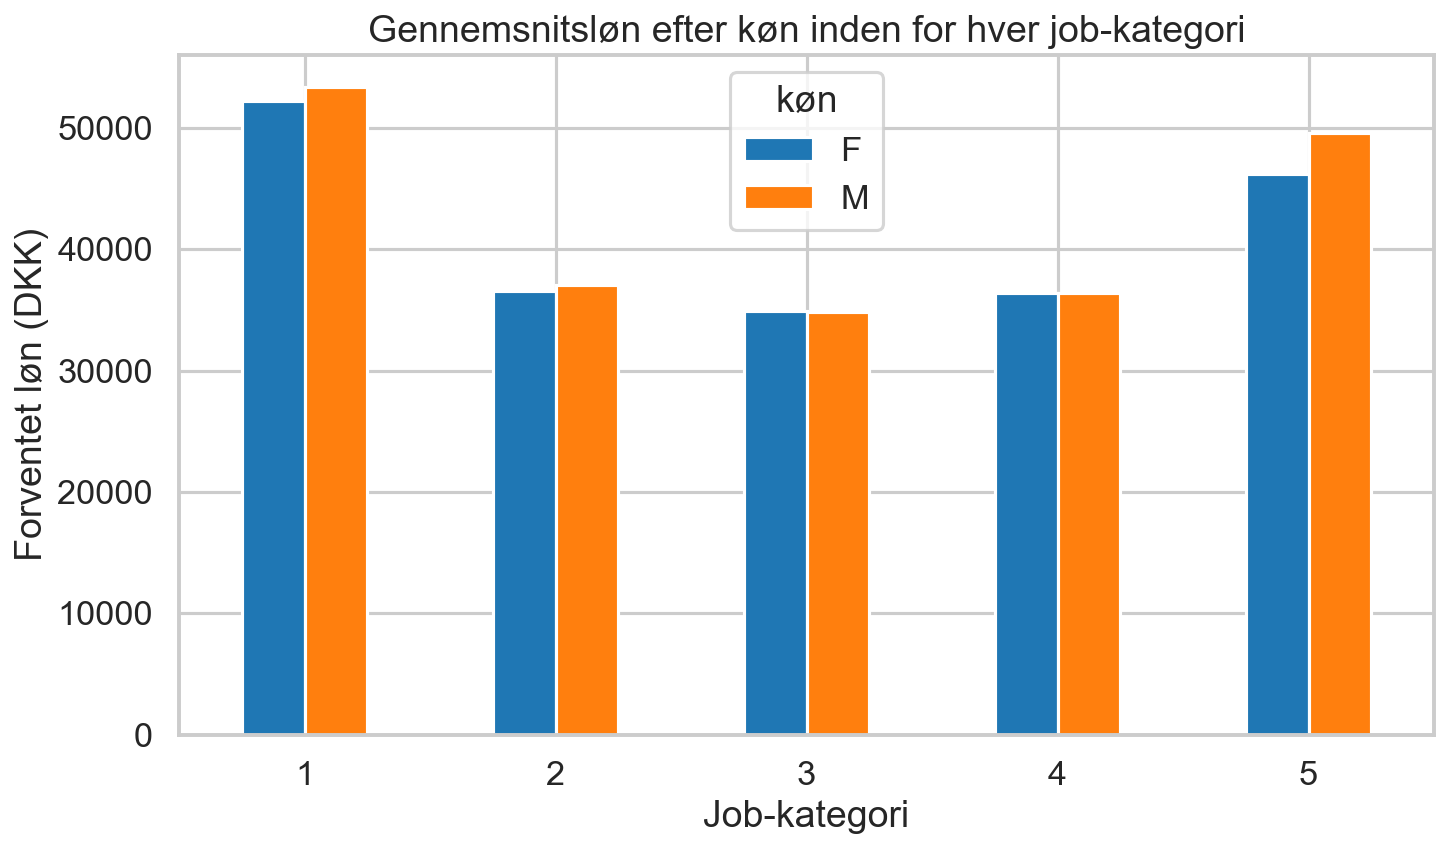

In [5]:
# job_gender_anova.py  -------------------------------------------------
# Kontrollerer:
#   1) Ligger de fem job-kategorier på forskellige lønniveauer?
#   2) Varierer kønsforskellen fra job til job?
# Indeholder desuden residual-normalitets­diagnostik.
# ---------------------------------------------------------------------
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import numpy as np

CSV = "/Users/vitusthaulow/Documents/GitHub/Project-in-Stat.-Eval.-02445/salaries_3000.csv"

# ---------- 1. Load & prep -------------------------------------------
cols = ["gender", "age", "occupation", "middle_salary"]
df   = pd.read_csv(CSV, usecols=cols)

for col in ["gender", "age", "occupation"]:
    df[col] = df[col].astype("category")

# ---------- 2. ANOVA (occupation × gender, kontrolleret for alder) ----
model = smf.ols("middle_salary ~ C(occupation)*C(gender) + C(age)", data=df).fit()
anova = sm.stats.anova_lm(model, typ=2)

print("\n=== 2-way ANOVA + alder ===")
print(anova.loc[["C(occupation)", "C(gender)", "C(occupation):C(gender)"]])

# ---------- 3. Residual-normalitet ------------------------------------
resid   = model.resid
resid_z = (resid - resid.mean()) / resid.std(ddof=1)

sm.qqplot(resid_z, line="45")
plt.title("Q–Q plot af standardiserede residualer")
plt.tight_layout()
plt.show()

plt.hist(resid_z, bins="auto", edgecolor="k")
plt.xlabel("Standardiseret residual")
plt.ylabel("Frekvens")
plt.title("Histogram over residualer")
plt.tight_layout()
plt.show()

w, p = st.shapiro(resid)
print(f"\nShapiro–Wilk: W = {w:.3f}, p = {p:.4g}")
print("→ Ingen evidens mod normalitet." if p > 0.05
      else "→ Residualerne afviger signifikant fra normalitet.")

# ---------- 4. Bar-plot (samme look-and-feel) -------------------------
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 150

colour_map = {"F": "#1f77b4", "M": "#ff7f0e"}     # blå / orange

mean_tbl = (df.groupby(["occupation", "gender"])["middle_salary"]
              .mean()
              .unstack())

ax = mean_tbl.loc[:, ["F", "M"]].plot(
        kind="bar", figsize=(10, 6), rot=0,
        color=[colour_map["F"], colour_map["M"]])

ax.set_xlabel("Job-kategori")
ax.set_ylabel("Forventet løn (DKK)")
ax.set_title("Gennemsnitsløn efter køn inden for hver job-kategori")
ax.legend(title="køn")

plt.tight_layout()
plt.show()

In [11]:
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.anova import permutation_anova

# model_log from earlier
anova_perm = permutation_anova(model_log, n_perm=9999, typ=2, seed=42)

print("\n=== Permutation ANOVA (log salary) ===")
print(anova_perm.loc[["C(gender)", "C(age)", "C(occupation)",
                      "C(gender):C(age)"]])

ImportError: cannot import name 'permutation_anova' from 'statsmodels.stats.anova' (/usr/local/Caskroom/miniconda/base/lib/python3.11/site-packages/statsmodels/stats/anova.py)